In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA Available: True
GPU: Tesla T4


In [ ]:
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")
project = rf.workspace("david-lee-d0rhs").project("american-sign-language-letters")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to American-Sign-Language-Letters-1 in yolov11:: 100%|██████████| 3468/3468 [00:00<00:00, 11296.68it/s]


In [ ]:
import os

dataset_path = dataset.location
print("Dataset path:", dataset_path)
print("\nFolders inside:")
for folder in os.listdir(dataset_path):
    folder_full = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_full):
        count = len(os.listdir(os.path.join(folder_full, "images"))) if os.path.exists(os.path.join(folder_full, "images")) else 0
        print(f"  📁 {folder}/ → {count} images")
    else:
        print(f"  📄 {folder}")

Dataset path: /content/American-Sign-Language-Letters-1

Folders inside:
  📄 data.yaml
  📄 README.roboflow.txt
  📁 valid/ → 144 images
  📁 test/ → 72 images
  📁 train/ → 1512 images
  📄 README.dataset.txt


In [ ]:
import yaml

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, default_flow_style=False))

names:
- A
- B
- C
- D
- E
- F
- G
- H
- I
- J
- K
- L
- M
- N
- O
- P
- Q
- R
- S
- T
- U
- V
- W
- X
- Y
- Z
nc: 26
roboflow:
  license: Public Domain
  project: american-sign-language-letters
  url: https://universe.roboflow.com/david-lee-d0rhs/american-sign-language-letters/dataset/1
  version: 1
  workspace: david-lee-d0rhs
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv11 nano model
model = YOLO("yolo11n.pt")

# Train!
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=-1,
    patience=10,
    device=0,
    project="sign_language",
    name="yolo11n_asl",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    flipud=0.0,
    fliplr=0.5,
    verbose=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/American-Sign-Language-Letters-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_asl, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

In [ ]:
from google.colab import files
files.download('/content/runs/detect/sign_language/yolo11n_asl/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# Load your best trained model
trained_model = YOLO('/content/runs/detect/sign_language/yolo11n_asl/weights/best.pt')

# Evaluate on test set
metrics = trained_model.val(
    data=yaml_path,
    split='test'
)

print("\n📊 Final Model Metrics:")
print(f"  mAP50:      {metrics.box.map50:.4f}")
print(f"  mAP50-95:   {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 636.1±262.8 MB/s, size: 17.5 KB)
val: Scanning /content/American-Sign-Language-Letters-1/test/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 2.1Kit/s 0.0s
val: New cache created: /content/American-Sign-Language-Letters-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.3it/s 2.2s
                   all         72         72      0.795      0.853      0.919      0.806
                     A          1          1      0.424          1      0.995      0.995
                     B          3          3      0.938          1      0.995      0.887
                     C          4          4      0.932          1      0.995      0.909
                     D          1       

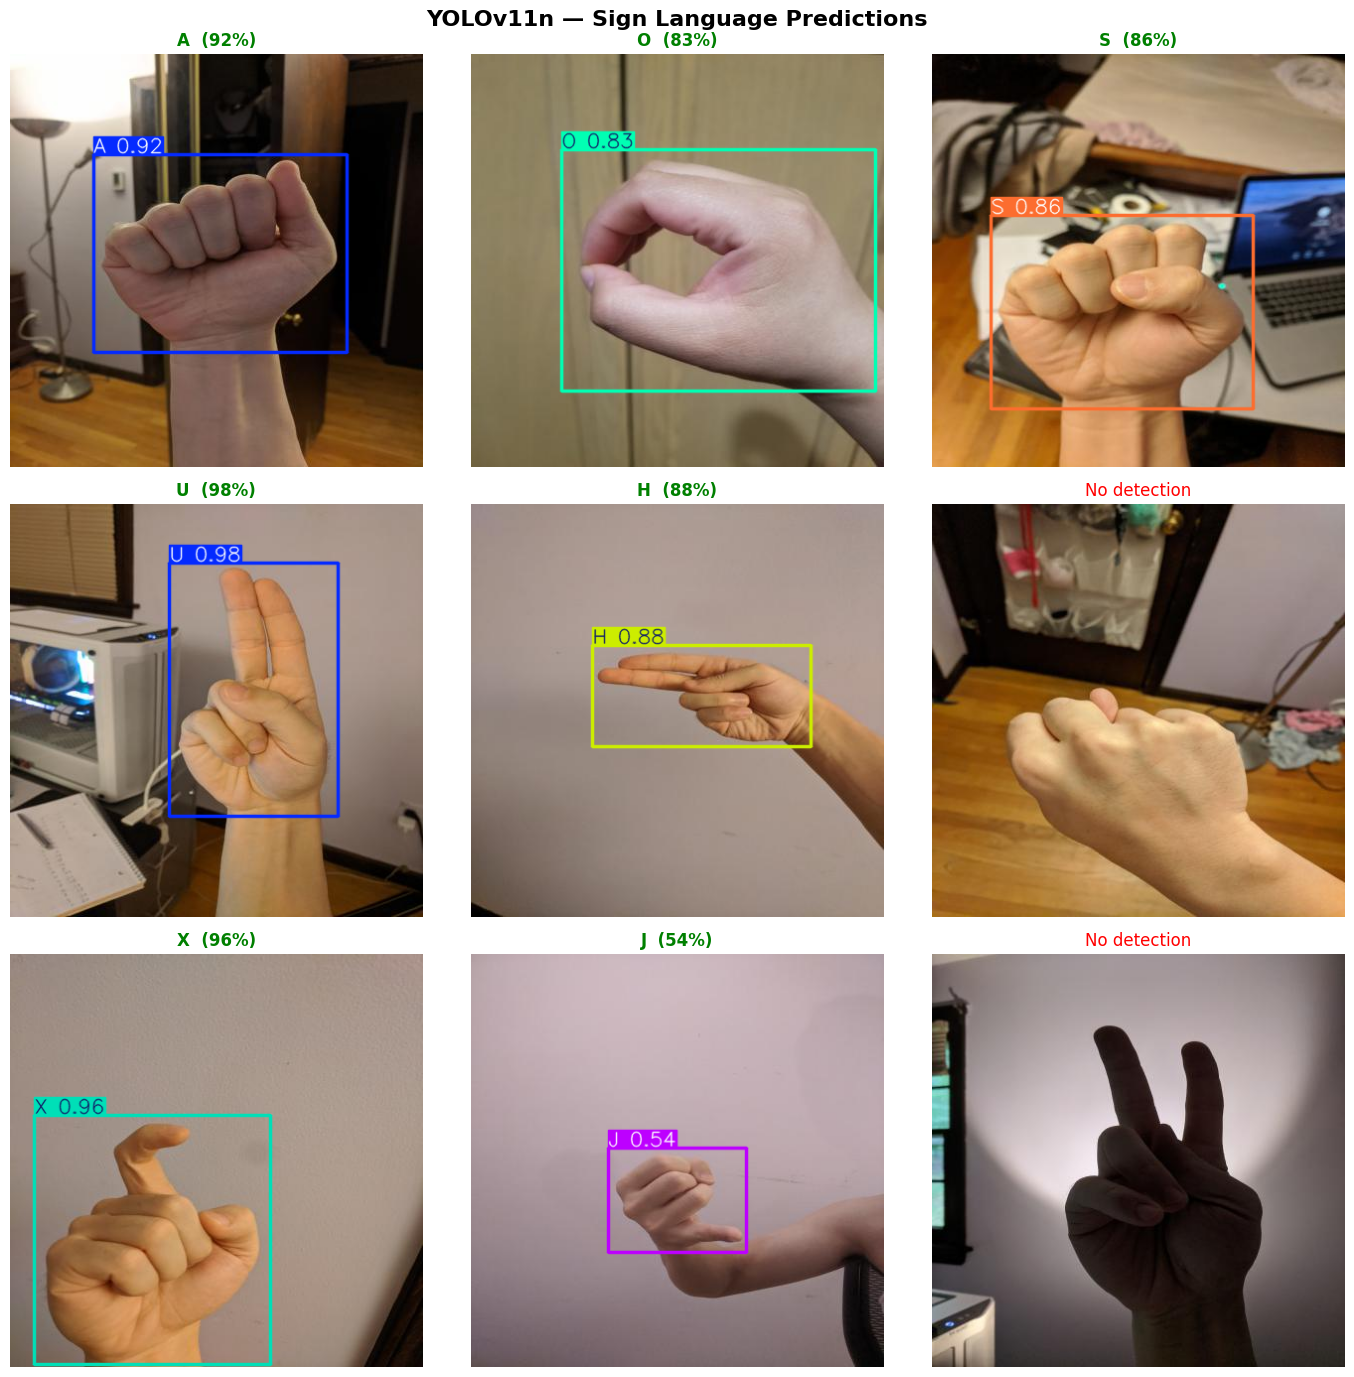

In [ ]:
import glob, random, cv2
import matplotlib.pyplot as plt

# Get test images
test_images = glob.glob('/content/American-Sign-Language-Letters-1/test/images/*.jpg')

# Pick 9 random samples
samples = random.sample(test_images, 9)

# Run prediction
results = trained_model.predict(source=samples, conf=0.5, verbose=False)

# Plot
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("YOLOv11n — Sign Language Predictions", fontsize=16, fontweight='bold')

for ax, result in zip(axes.flatten(), results):
    img = result.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    if result.boxes and len(result.boxes) > 0:
        cls = int(result.boxes.cls[0].item())
        conf = result.boxes.conf[0].item()
        ax.set_title(f"{result.names[cls]}  ({conf:.0%})", fontsize=12, fontweight='bold', color='green')
    else:
        ax.set_title("No detection", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Your_api_key")
project = rf.workspace("samikshyas-workspace").project("asl-merged-lvrf1")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ASL-Merged-1 in yolov11:: 100%|██████████| 10749/10749 [00:04<00:00, 2255.08it/s]


In [ ]:
import os

dataset_path = dataset.location
print("Dataset path:", dataset_path)
print("\nFolders inside:")
for folder in os.listdir(dataset_path):
    folder_full = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_full):
        count = len(os.listdir(os.path.join(folder_full, "images"))) if os.path.exists(os.path.join(folder_full, "images")) else 0
        print(f"  📁 {folder}/ → {count} images")
    else:
        print(f"  📄 {folder}")

Dataset path: /content/ASL-Merged-1

Folders inside:
  📄 data.yaml
  📁 test/ → 218 images
  📁 valid/ → 429 images
  📁 train/ → 4725 images
  📄 README.roboflow.txt
  📄 README.dataset.txt


In [ ]:
import yaml

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, default_flow_style=False))

names:
- A
- B
- C
- D
- E
- F
- G
- H
- I
- J
- K
- L
- M
- N
- O
- P
- Q
- R
- S
- T
- U
- V
- W
- X
- Y
- Z
nc: 26
roboflow:
  license: Public Domain
  project: asl-merged-lvrf1
  url: https://universe.roboflow.com/samikshyas-workspace/asl-merged-lvrf1/dataset/1
  version: 1
  workspace: samikshyas-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from google.colab import files
uploaded = files.upload()  # select your best.pt file

Saving best.pt to best.pt


In [ ]:
from ultralytics import YOLO
import os

# Load uploaded model
trained_model = YOLO('/content/best.pt')
print("✅ Model loaded!")
print(f"Number of classes: {len(trained_model.names)}")

✅ Model loaded!
Number of classes: 26


In [ ]:
import os
import yaml

# Set paths
dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, "data.yaml")

# Evaluate on test set
metrics = trained_model.val(
    data=yaml_path,
    split='test'
)

print("\n📊 Final Model Metrics:")
print(f"  mAP50:      {metrics.box.map50:.4f}")
print(f"  mAP50-95:   {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1579.6±869.4 MB/s, size: 84.6 KB)
val: Scanning /content/ASL-Merged-1/test/labels... 218 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 218/218 1.4Kit/s 0.2s
val: New cache created: /content/ASL-Merged-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.8it/s 5.0s
                   all        218        218      0.972      0.938      0.986      0.752
                     A          7          7      0.974          1      0.995      0.799
                     B          9          9          1      0.994      0.995      0.739
                     C          7          7      0.923          1      0.995      0.813
                     D          4          4      0.971          1      0.

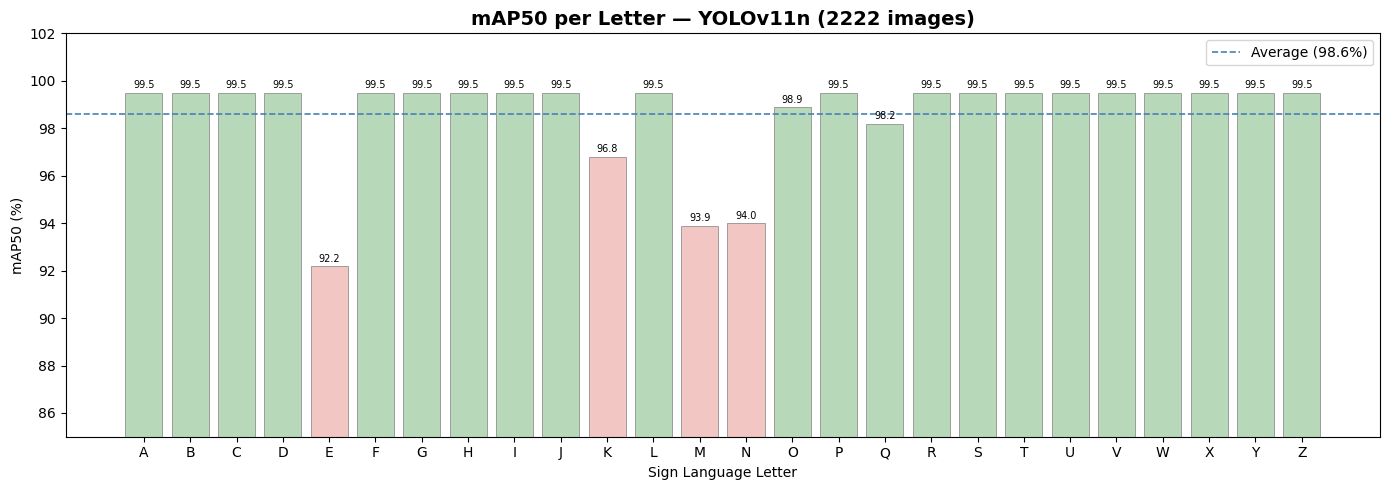

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = [chr(i) for i in range(ord('A'), ord('Z')+1)]
map50_scores = [
    0.995, 0.995, 0.995, 0.995, 0.922, 0.995, 0.995, 0.995,
    0.995, 0.995, 0.968, 0.995, 0.939, 0.940, 0.989, 0.995,
    0.982, 0.995, 0.995, 0.995, 0.995, 0.995, 0.995, 0.995,
    0.995, 0.995
]

colors = ['#B8D8BA' if s >= 0.98 else '#F2C6C2' for s in map50_scores]

plt.figure(figsize=(14, 5))
bars = plt.bar(classes, [s*100 for s in map50_scores], color=colors, edgecolor='gray', linewidth=0.5)

for bar, score in zip(bars, map50_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{score*100:.1f}', ha='center', va='bottom', fontsize=7)

plt.title("mAP50 per Letter — YOLOv11n (2222 images)", fontsize=14, fontweight='bold')
plt.xlabel("Sign Language Letter")
plt.ylabel("mAP50 (%)")
plt.ylim(85, 102)
plt.axhline(y=98.6, color='steelblue', linestyle='--', linewidth=1.2, label='Average (98.6%)')
plt.legend()
plt.tight_layout()
plt.show()


📊 BoxF1_curve.png


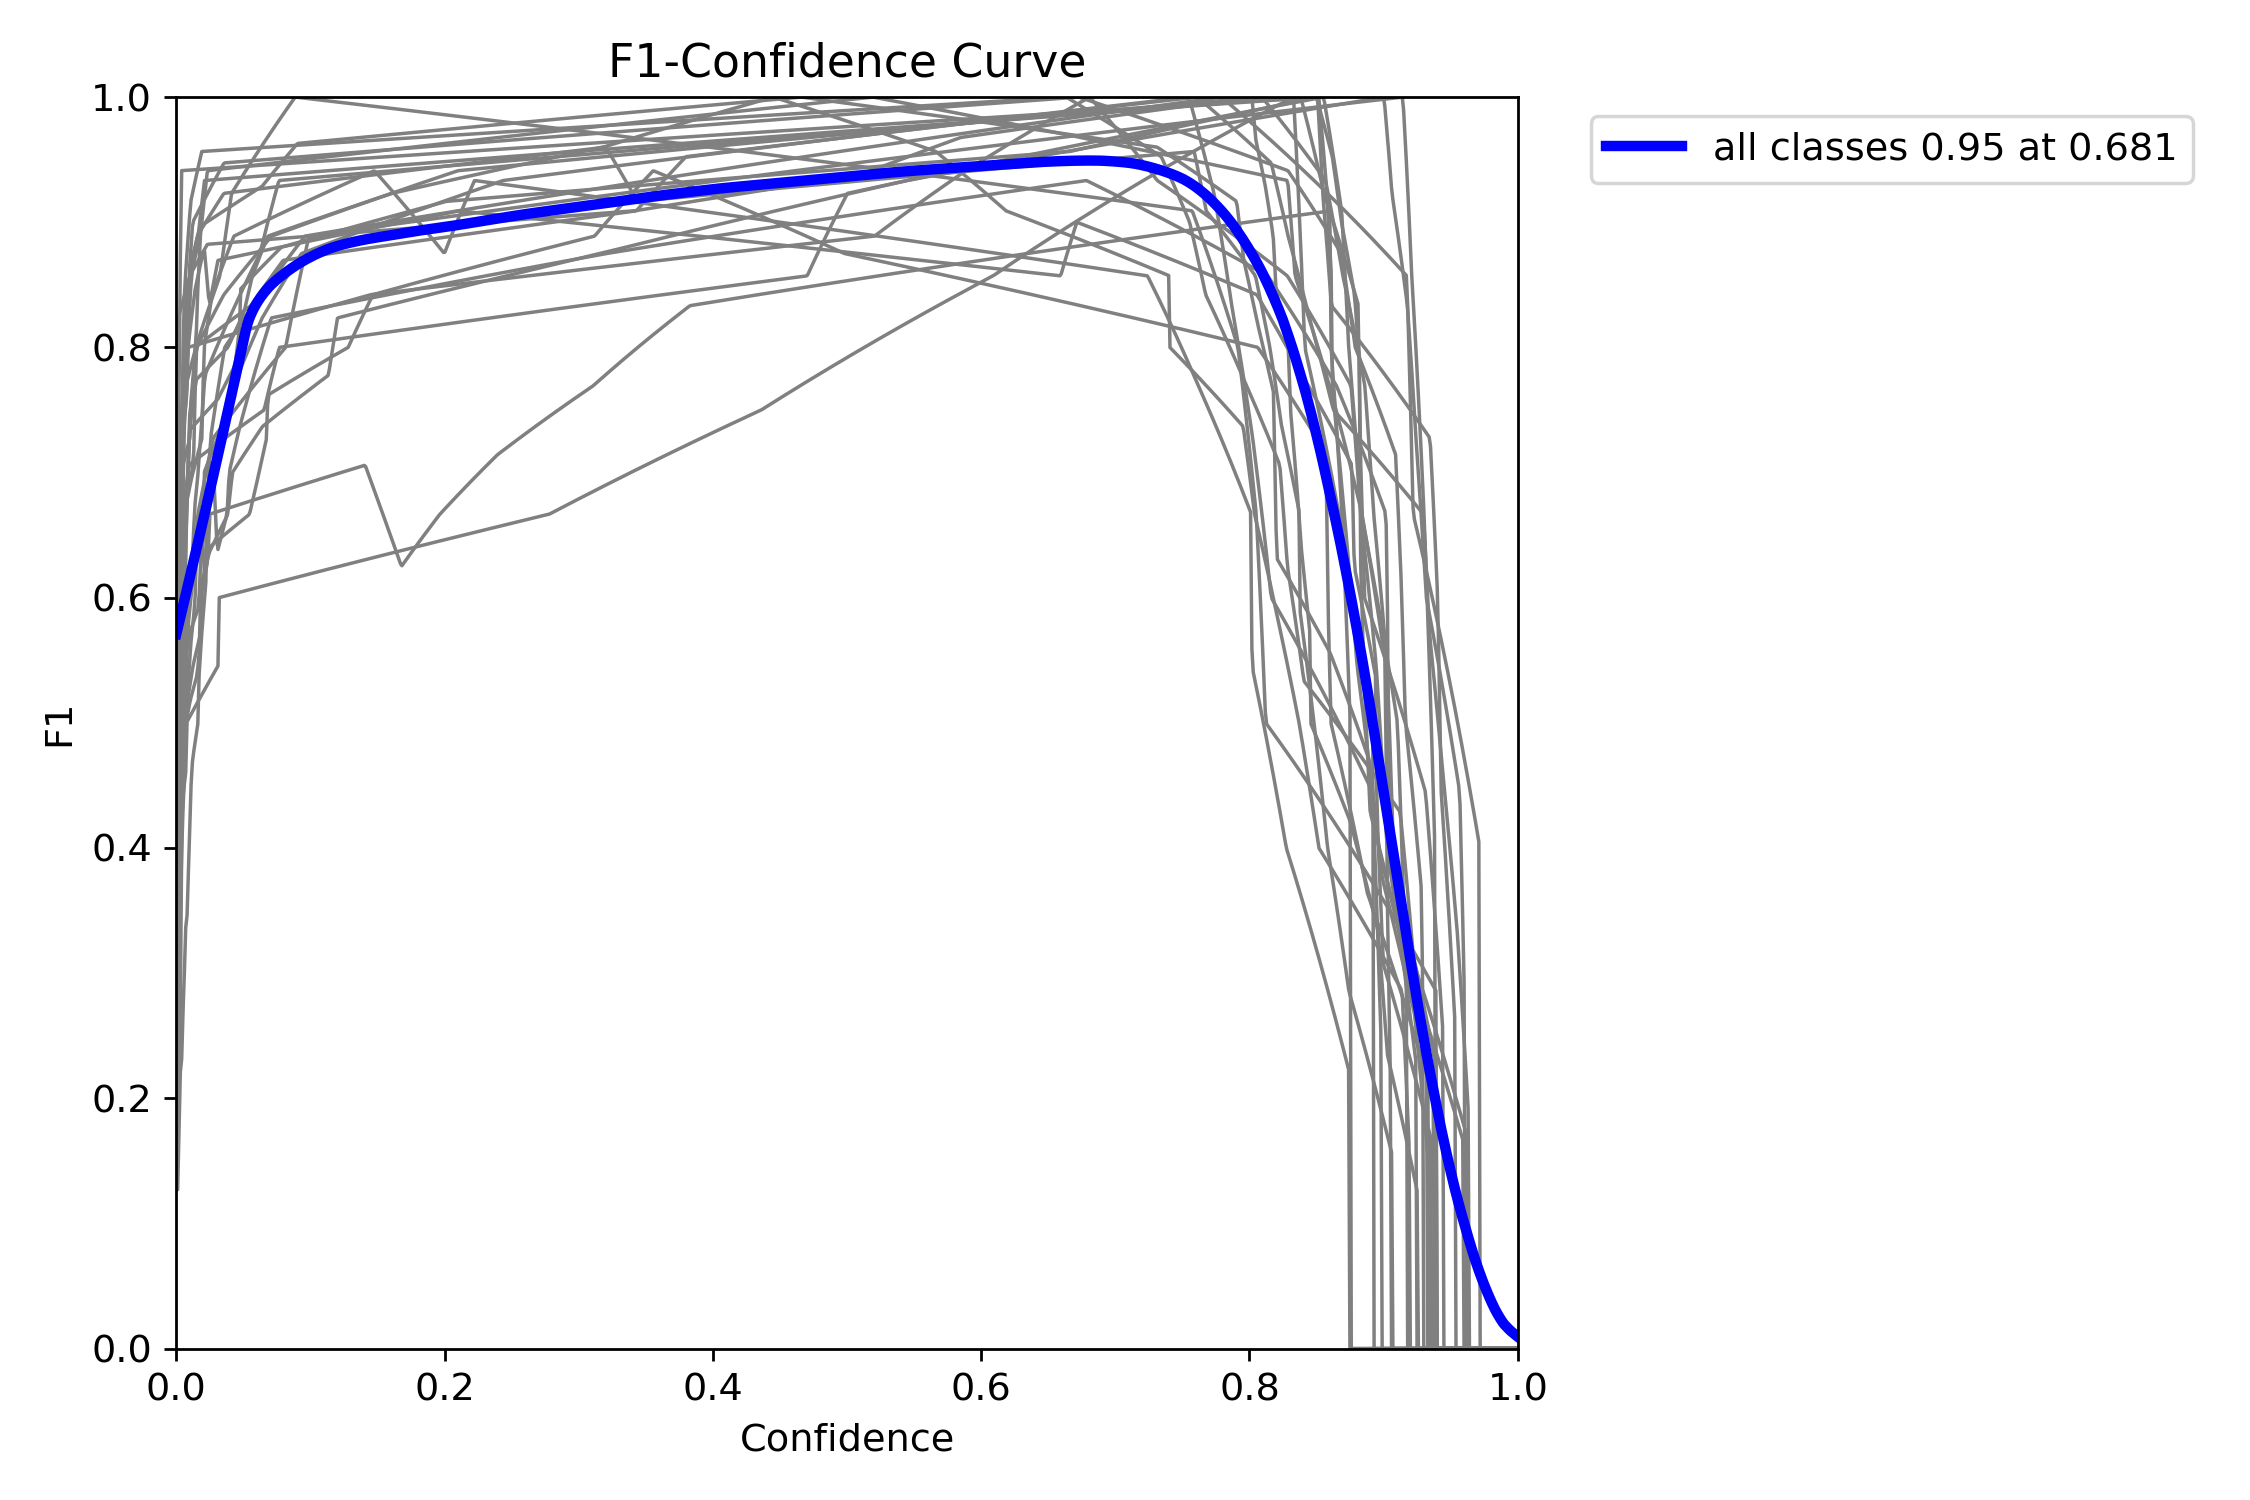


📊 BoxPR_curve.png


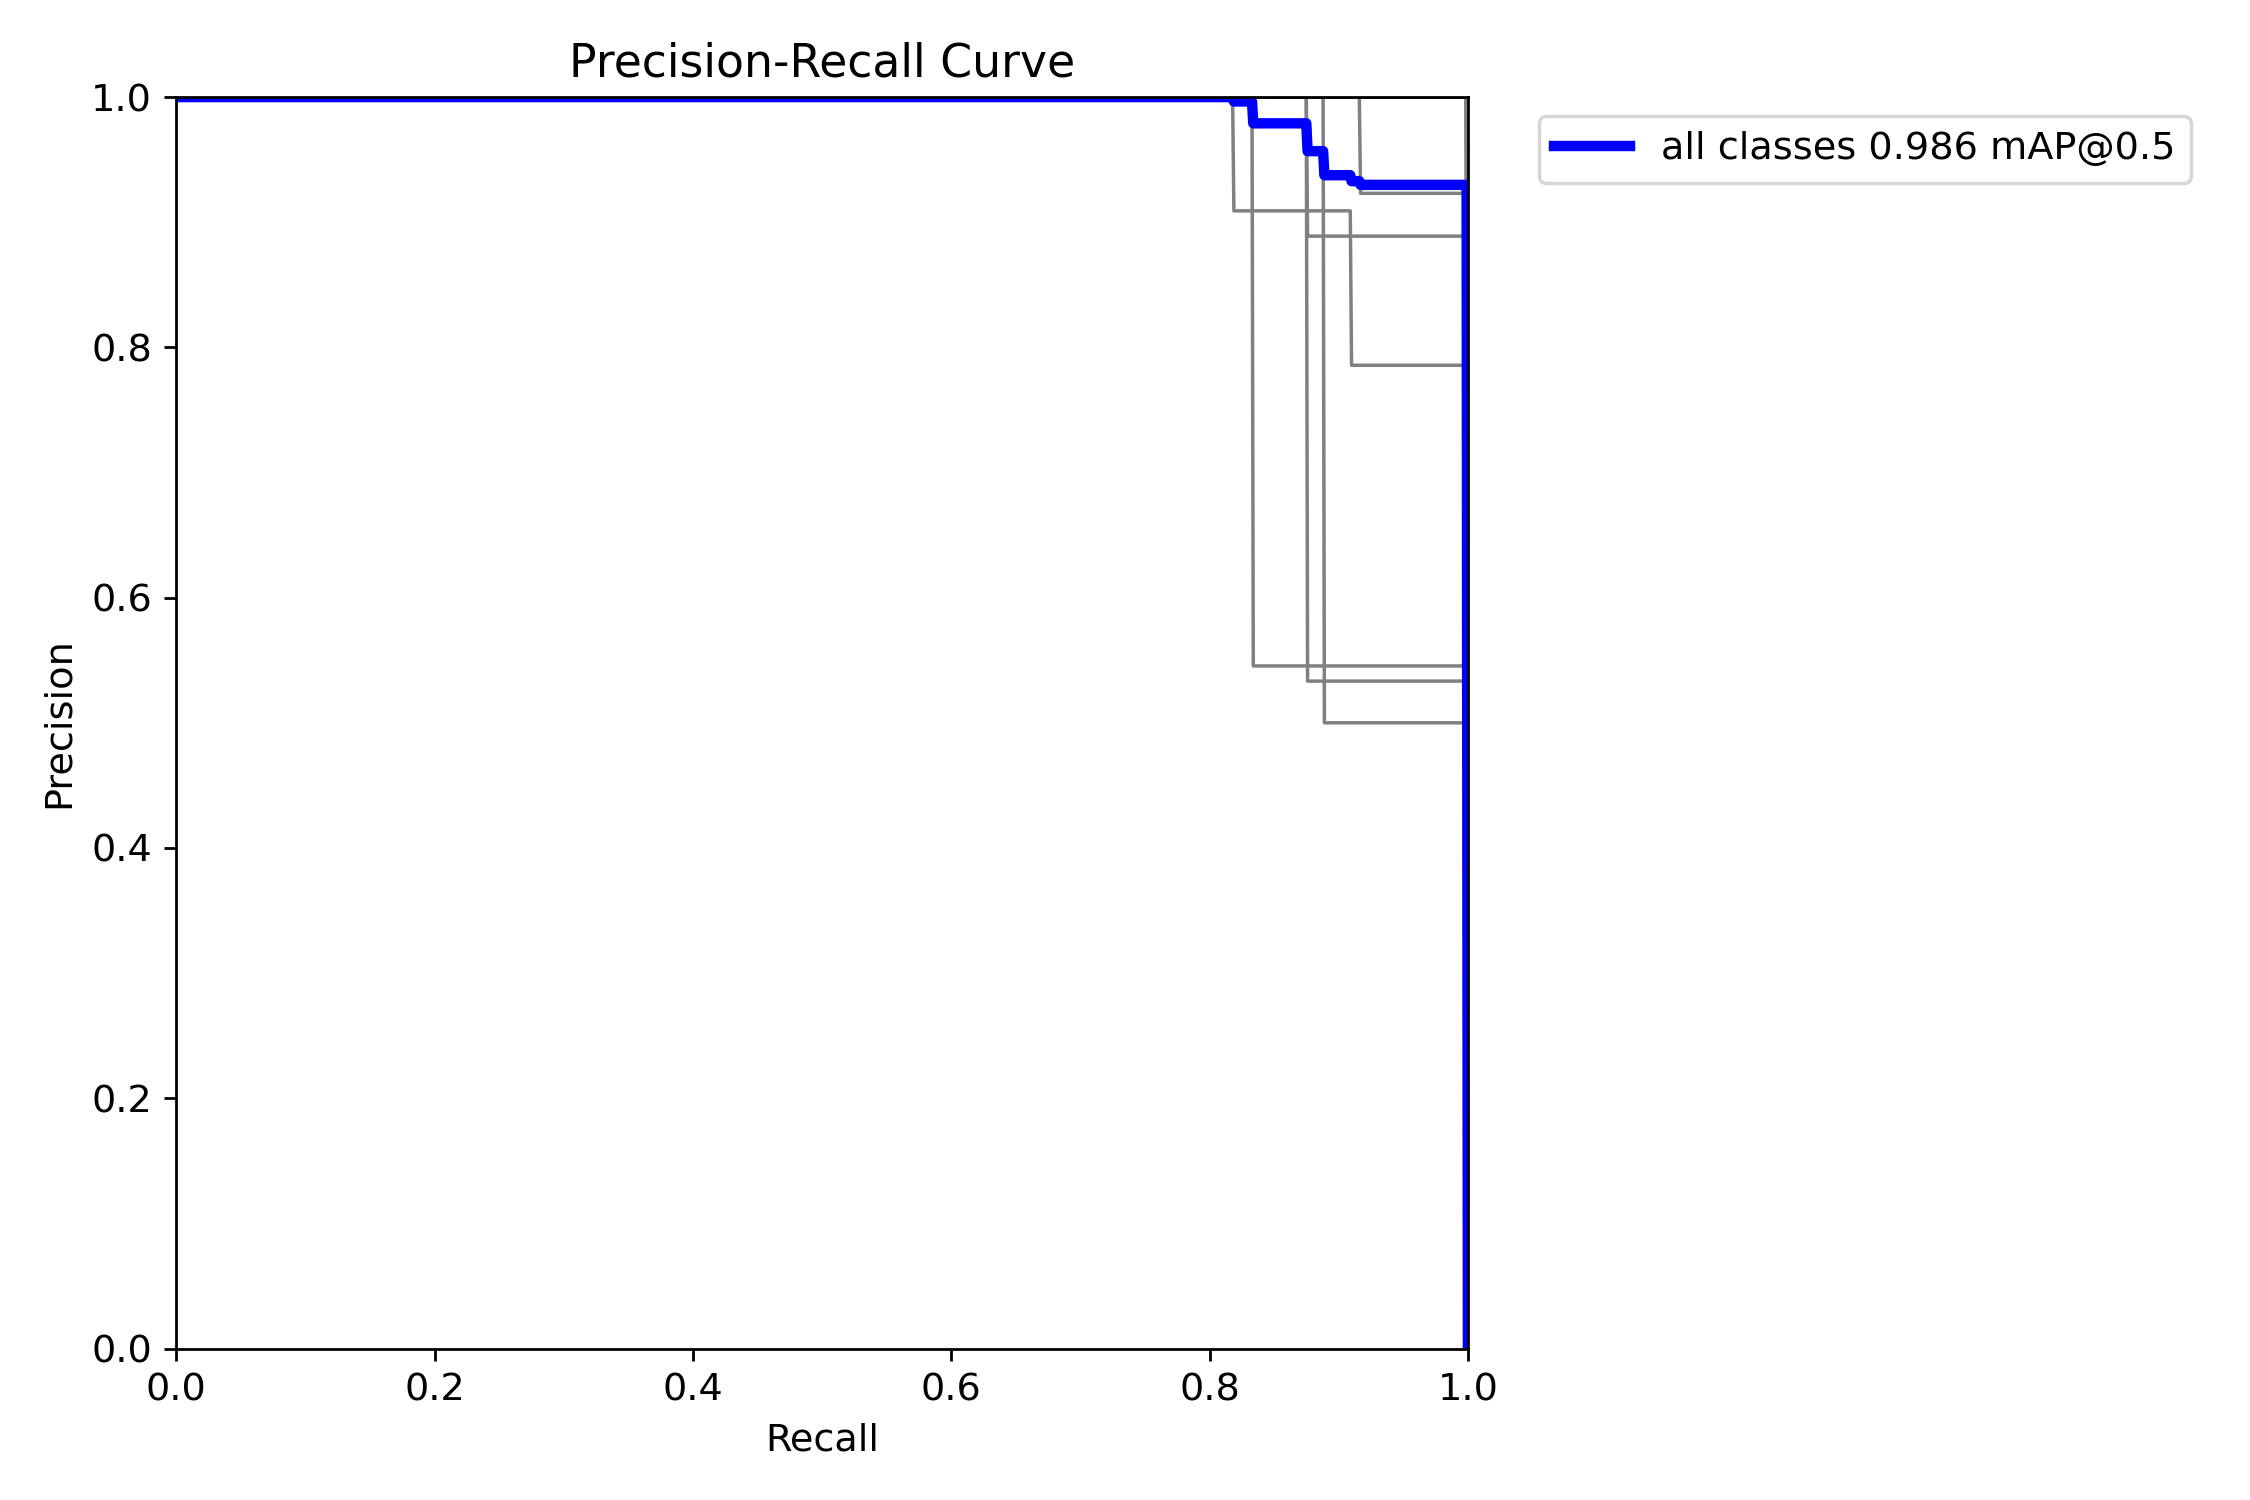


📊 confusion_matrix_normalized.png


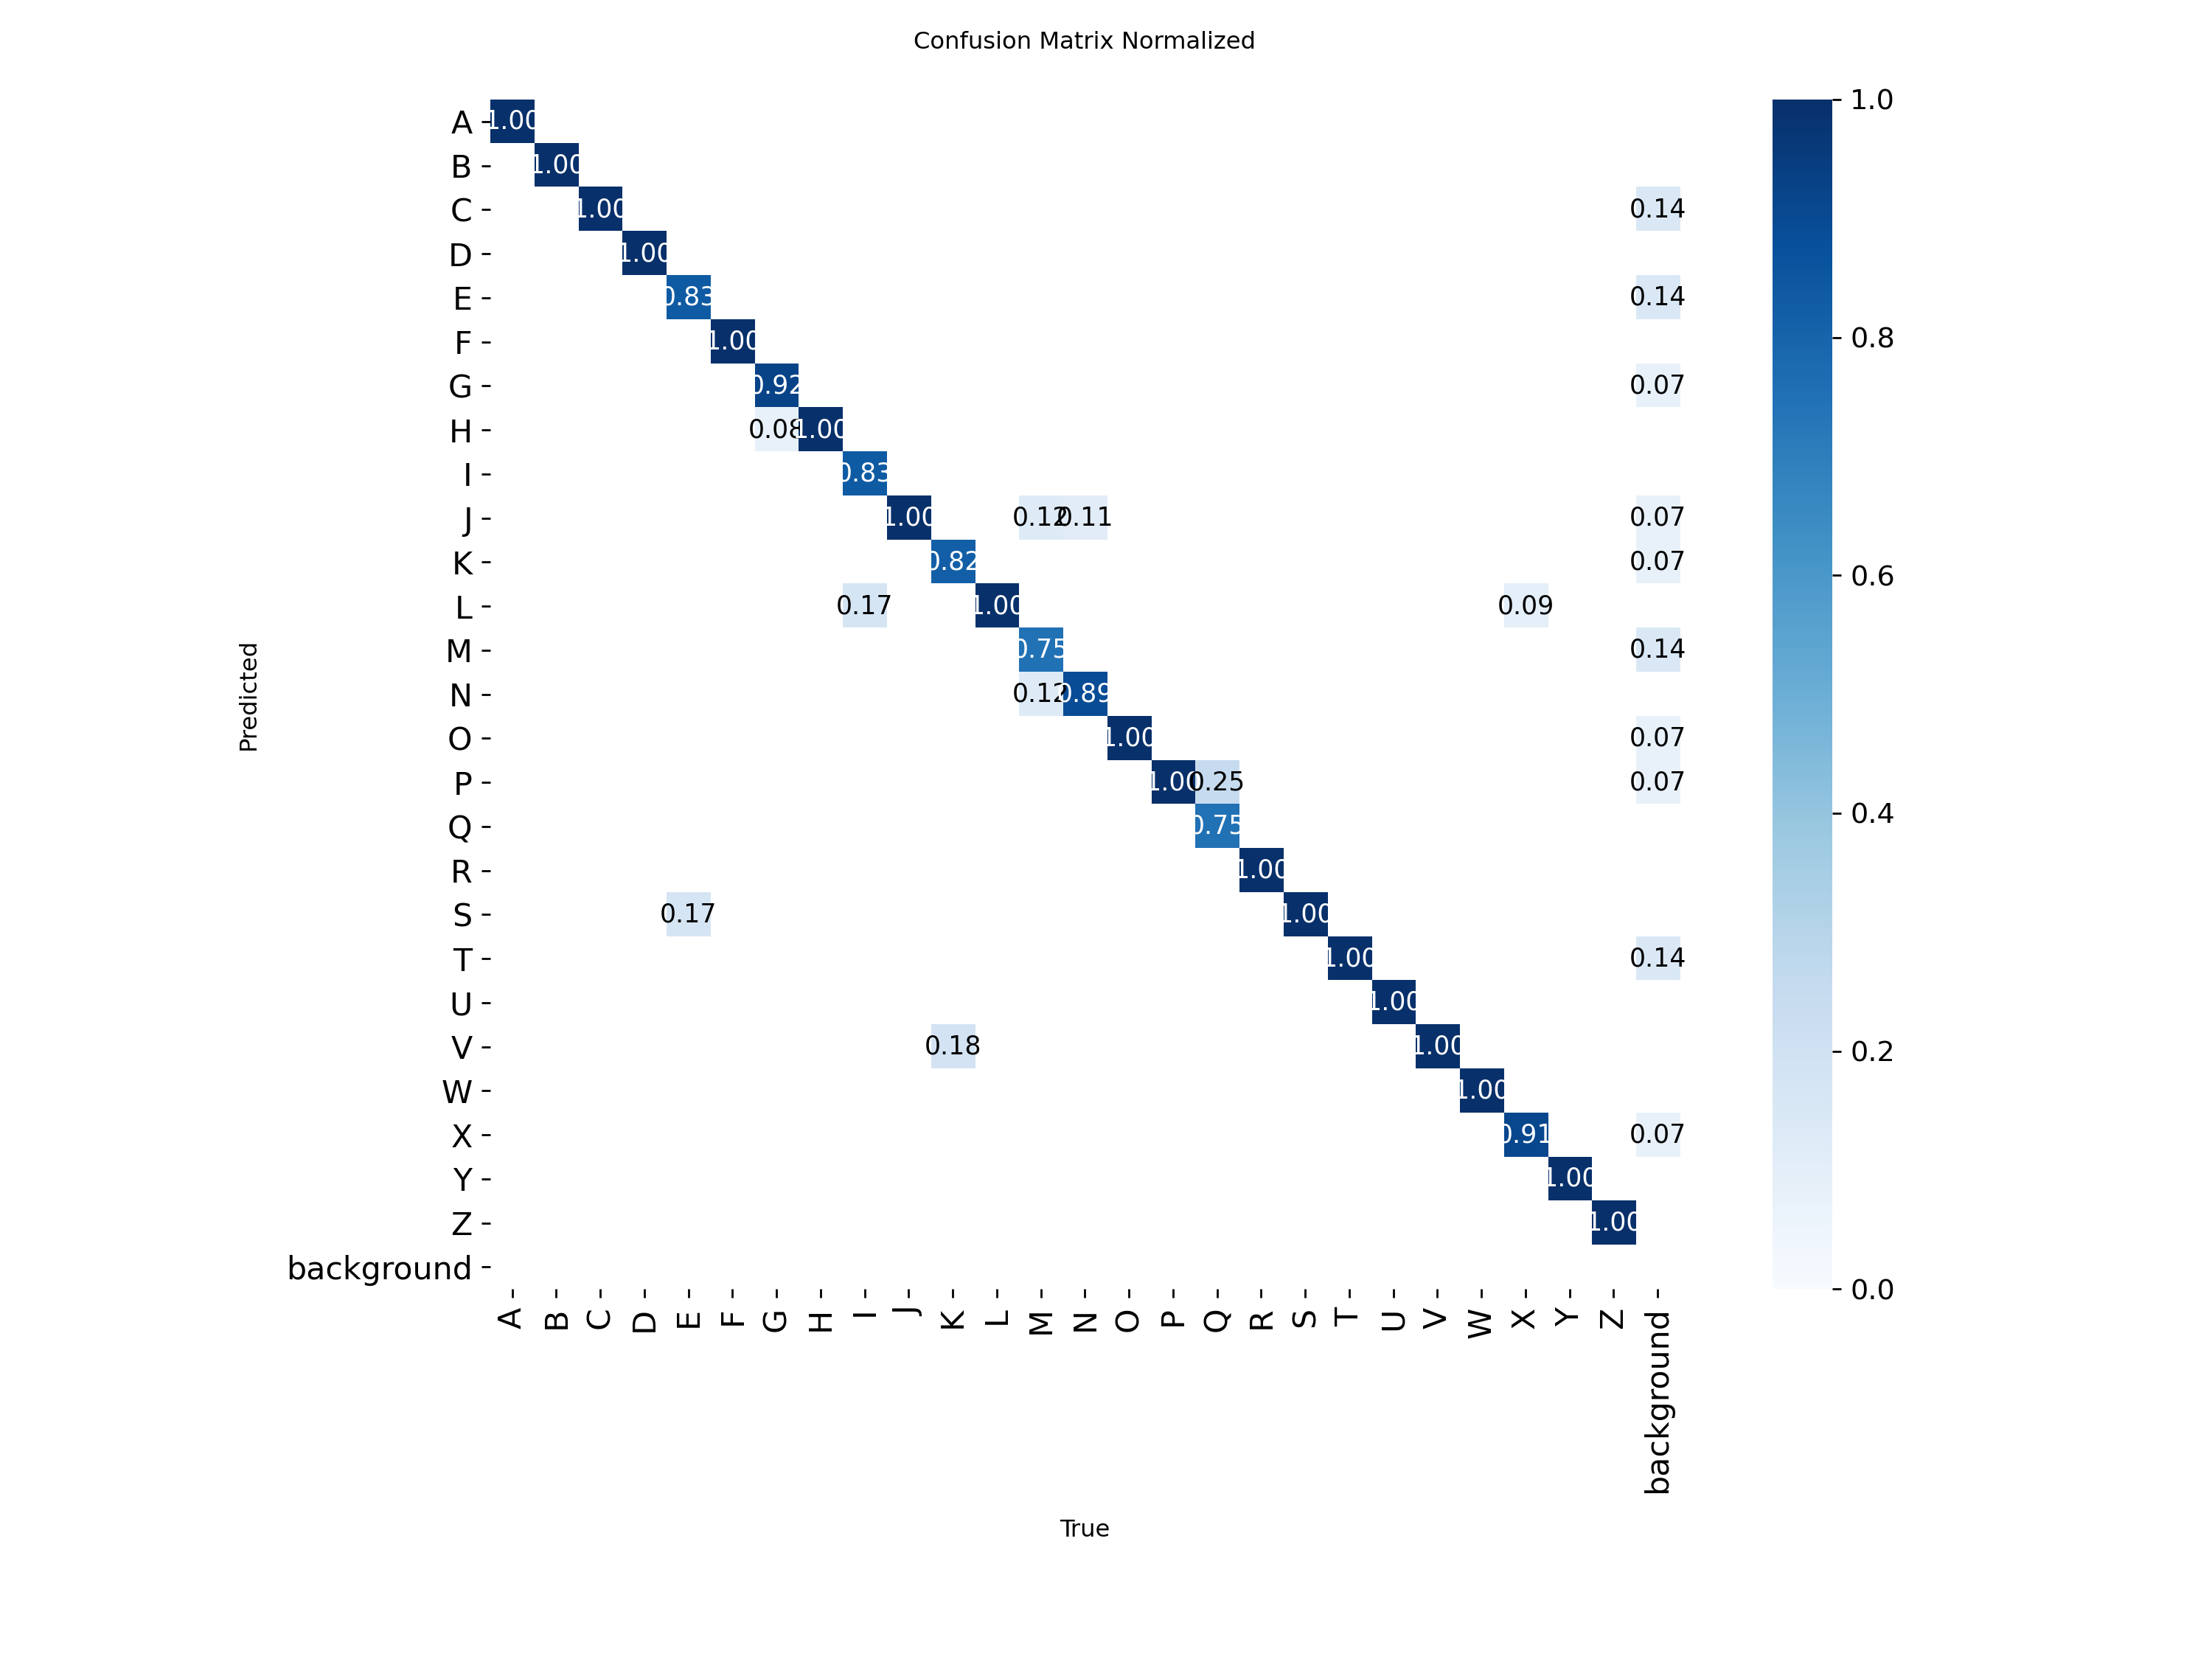

In [ ]:
from IPython.display import Image, display
import glob

val_path = '/content/runs/detect/val/'

for img in ['BoxF1_curve.png', 'BoxPR_curve.png',
            'confusion_matrix_normalized.png']:
    print(f"\n📊 {img}")
    display(Image(filename=val_path + img, width=700))

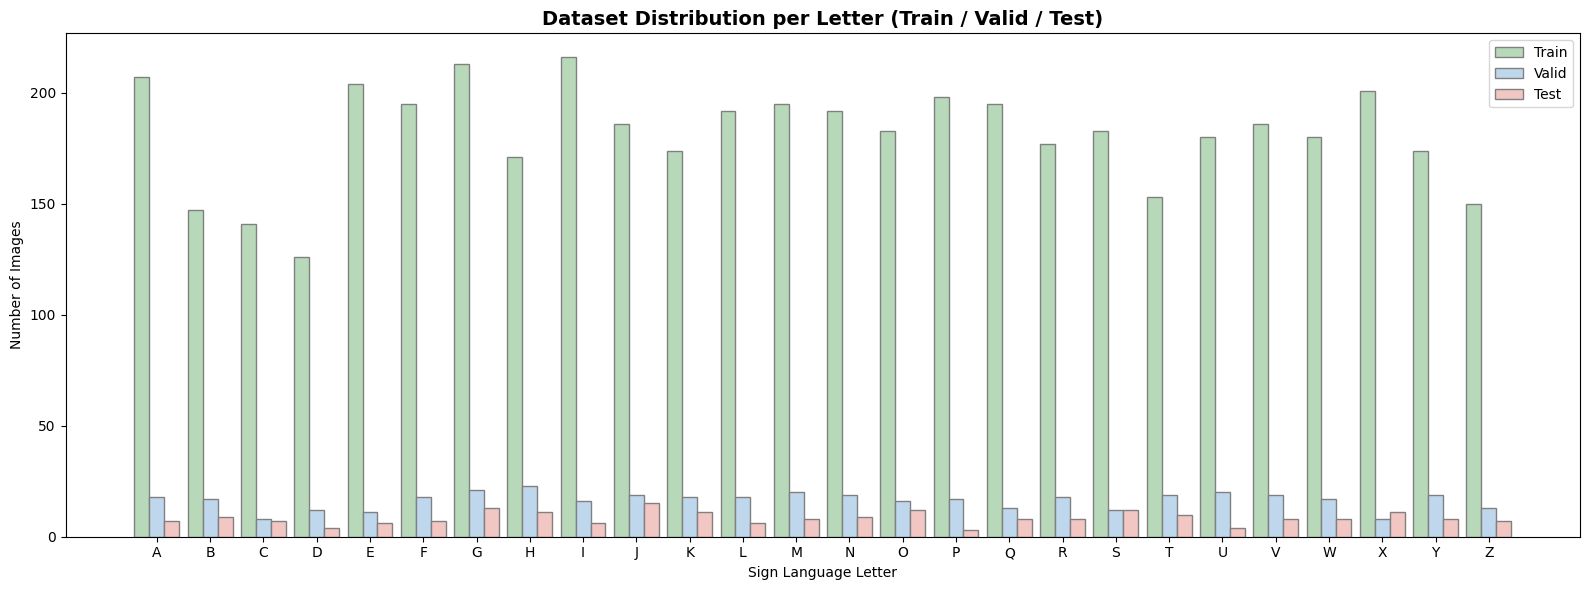

Train  total: 4719 images
Valid  total: 429 images
Test   total: 218 images
Grand total: 5366 images


In [ ]:
import os
from collections import defaultdict
import matplotlib.pyplot as plt

dataset_path = dataset.location
class_names = [chr(i) for i in range(ord('A'), ord('Z')+1)]

# Count for each split
splits = ['train', 'valid', 'test']
split_counts = {}

for split in splits:
    labels_path = os.path.join(dataset_path, split, 'labels')
    class_count = defaultdict(int)
    if os.path.exists(labels_path):
        for label_file in os.listdir(labels_path):
            if label_file.endswith('.txt'):
                with open(os.path.join(labels_path, label_file), 'r') as f:
                    for line in f:
                        class_id = int(line.strip().split()[0])
                        class_count[class_id] += 1
    split_counts[split] = [class_count[i] for i in range(26)]

# Plot
x = range(26)
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar([i - width for i in x], split_counts['train'], width, label='Train', color='#B8D8BA', edgecolor='gray')
bars2 = ax.bar([i for i in x],         split_counts['valid'], width, label='Valid', color='#BFD7ED', edgecolor='gray')
bars3 = ax.bar([i + width for i in x], split_counts['test'],  width, label='Test',  color='#F2C6C2', edgecolor='gray')

ax.set_xticks(list(x))
ax.set_xticklabels(class_names)
ax.set_xlabel('Sign Language Letter')
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Distribution per Letter (Train / Valid / Test)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Print totals
for split in splits:
    print(f"{split.capitalize():6} total: {sum(split_counts[split])} images")
print(f"Grand total: {sum(sum(split_counts[s]) for s in splits)} images")

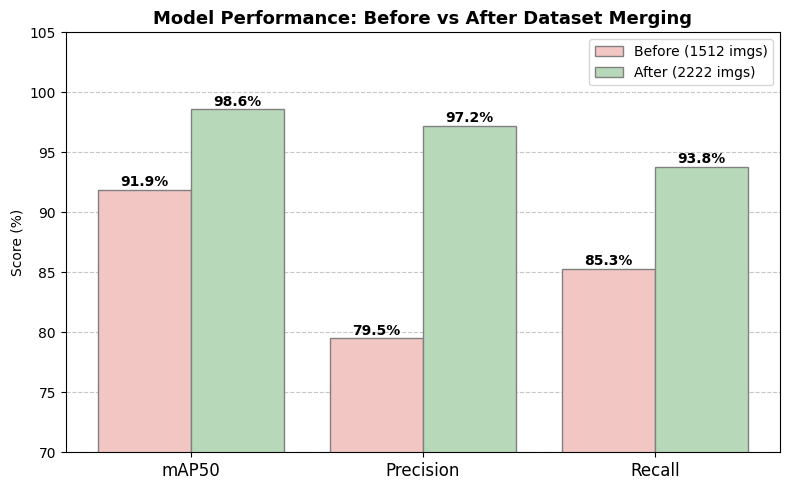

In [ ]:
import matplotlib.pyplot as plt

metrics = ['mAP50', 'Precision', 'Recall']
before = [91.9, 79.5, 85.3]
after =  [98.6, 97.2, 93.8]

x = range(len(metrics))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - 0.2 for i in x], before, 0.4, label='Before (1512 imgs)', color='#F2C6C2', edgecolor='gray')
ax.bar([i + 0.2 for i in x], after,  0.4, label='After (2222 imgs)',  color='#B8D8BA', edgecolor='gray')

for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - 0.2, b + 0.3, f'{b}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + 0.2, a + 0.3, f'{a}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_ylim(70, 105)
ax.set_title('Model Performance: Before vs After Dataset Merging',
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import shutil
shutil.make_archive('training_results', 'zip', 'runs/detect/sign_language/yolo11n_asl')
files.download('training_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>